In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

file_path = '/content/drive/MyDrive/CapstoneCYBER/cleaned_data.csv'
df = pd.read_csv(file_path)
display(df.head())

,URL,URLLength,DomainLength,TLD,URLSimilarityIndex,NumSpecialChars,HasHTTP,HasWWW,label
0,https://www.southbankmosaics.com,32,24,com,100.0,0,1,1,1
1,https://www.uni-mainz.de,24,16,de,100.0,0,1,1,1
2,https://www.voicefmradio.co.uk,30,22,uk,100.0,0,1,1,1
3,https://www.sfnmjournal.com,27,19,com,100.0,0,1,1,1
4,https://www.rewildingargentina.org,34,26,org,100.0,0,1,1,1


In [3]:
print('Missing values before handling:')
display(df.isnull().sum())

Missing values before handling:


,0
URL,0
URLLength,0
DomainLength,0
TLD,0
URLSimilarityIndex,0
NumSpecialChars,0
HasHTTP,0
HasWWW,0
label,0


### Handle Duplicate Records

In [4]:
print(f"Number of duplicate rows before dropping: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Number of rows after dropping duplicates: {len(df)}")

Number of duplicate rows before dropping: 404
Number of rows after dropping duplicates: 235391


### Outlier Detection and Treatment

Outliers can significantly impact model performance. We will use the IQR (Interquartile Range) method to detect outliers, which is robust to extreme values.
This code identifies all numerical columns in your dataset. For each numerical column, it calculates the Interquartile Range (IQR) to find values that are significantly outside the typical range, which are considered outliers. Finally, it displays how many outliers were found in each numerical column and provides a summary of the statistics for these columns.

In [5]:
# Select only numerical columns for outlier detection
numerical_cols = df.select_dtypes(include=['number']).columns

print("Numerical columns identified for outlier detection:")
print(numerical_cols.tolist())

# Initialize a dictionary to store outlier counts for each numerical column
outlier_counts = {}

# Loop through each numerical column to detect outliers using IQR method
for column in numerical_cols:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    # Define outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Detect outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    # Store the count of outliers
    outlier_counts[column] = len(outliers)

# Display outlier counts
print("\nNumber of outliers detected per numerical column (using IQR method):")
for col, count in outlier_counts.items():
    print(f"{col}: {count}")

# Display descriptive statistics of numerical columns to get a better sense of value ranges
print("\nDescriptive statistics for numerical columns:")
display(df[numerical_cols].describe())

Numerical columns identified for outlier detection:
['URLLength', 'DomainLength', 'URLSimilarityIndex', 'NumSpecialChars', 'HasHTTP', 'HasWWW', 'label']

Number of outliers detected per numerical column (using IQR method):
URLLength: 21822
DomainLength: 13375
URLSimilarityIndex: 0
NumSpecialChars: 4846
HasHTTP: 0
HasWWW: 58307
label: 0

Descriptive statistics for numerical columns:


,URLLength,DomainLength,URLSimilarityIndex,NumSpecialChars,HasHTTP,HasWWW,label
count,235391.000000,235391.000000,235391.000000,235391.000000,235391.0,235391.000000,235391.000000
mean,35.341589,21.456160,78.493723,0.073210,1.0,0.752297,0.572877
std,41.232372,9.128686,28.950099,1.070435,0.0,0.431679,0.494662
min,14.000000,4.000000,0.155574,0.000000,1.0,0.000000,0.000000
25%,24.000000,16.000000,57.158120,0.000000,1.0,1.000000,0.000000
50%,28.000000,20.000000,100.000000,0.000000,1.0,1.000000,1.000000
75%,35.000000,24.000000,100.000000,0.000000,1.0,1.000000,1.000000
max,6097.000000,110.000000,100.000000,149.000000,1.0,1.000000,1.000000


To visualize the outliers, let's use box plots for each numerical feature. This will give us a clear view of the distribution and any extreme values.

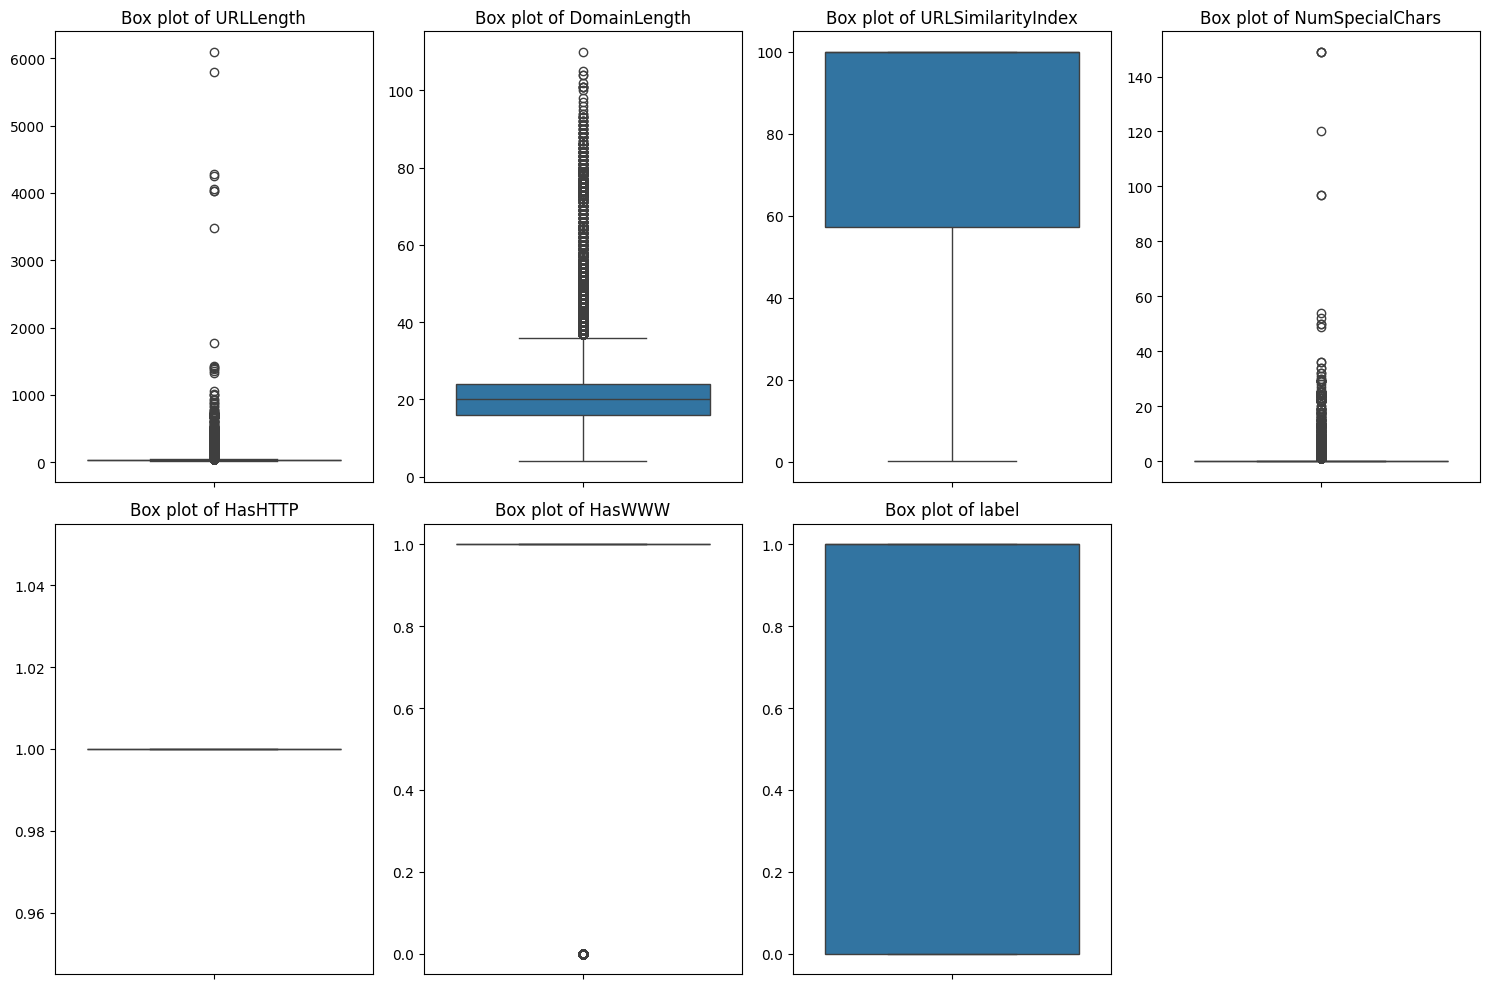

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create box plots for each numerical column to visualize outliers
plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_cols):
    plt.subplot(2, 4, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[column])
    plt.title(f'Box plot of {column}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

Based on the outlier detection and visualizations, we can now decide on a treatment strategy. Common approaches include:

*   **Removal:** If outliers are few and clearly erroneous.
*   **Capping (Winsorization):** Replacing outliers with the nearest non-outlier value.
*   **Transformation:** Applying mathematical transformations (e.g., log, square root) to reduce the impact of outliers.


### Outlier Treatment: Capping (Winsorization)

Capping, also known as Winsorization, is a method used to handle outliers in data. Imagine you have a range of values, and some are extremely high or extremely low compared to the rest. Capping works by setting a 'cap' at a certain upper limit and a 'floor' at a lower limit. Any value that falls above the upper limit is replaced with the upper limit value, and any value below the lower limit is replaced with the lower limit value. This prevents extreme values from unduly influencing your analysis or machine learning models, effectively 'clipping' them to a more reasonable range.

In [7]:
# Apply capping (Winsorization) to the identified numerical columns

columns_to_cap = ['URLLength', 'DomainLength', 'NumSpecialChars']

print("Applying capping to the following columns:", columns_to_cap)

for column in columns_to_cap:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values outside the bounds
    df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    print(f"Capping applied to {column}. New min: {df[column].min():.2f}, New max: {df[column].max():.2f}")

print("\nDescriptive statistics for capped numerical columns:")
display(df[columns_to_cap].describe())

Applying capping to the following columns: ['URLLength', 'DomainLength', 'NumSpecialChars']
Capping applied to URLLength. New min: 14.00, New max: 51.50
Capping applied to DomainLength. New min: 4.00, New max: 36.00
Capping applied to NumSpecialChars. New min: 0.00, New max: 0.00

Descriptive statistics for capped numerical columns:


,URLLength,DomainLength,NumSpecialChars
count,235391.000000,235391.000000,235391.0
mean,30.993402,20.763585,0.0
std,9.254258,6.719343,0.0
min,14.000000,4.000000,0.0
25%,24.000000,16.000000,0.0
50%,28.000000,20.000000,0.0
75%,35.000000,24.000000,0.0
max,51.500000,36.000000,0.0


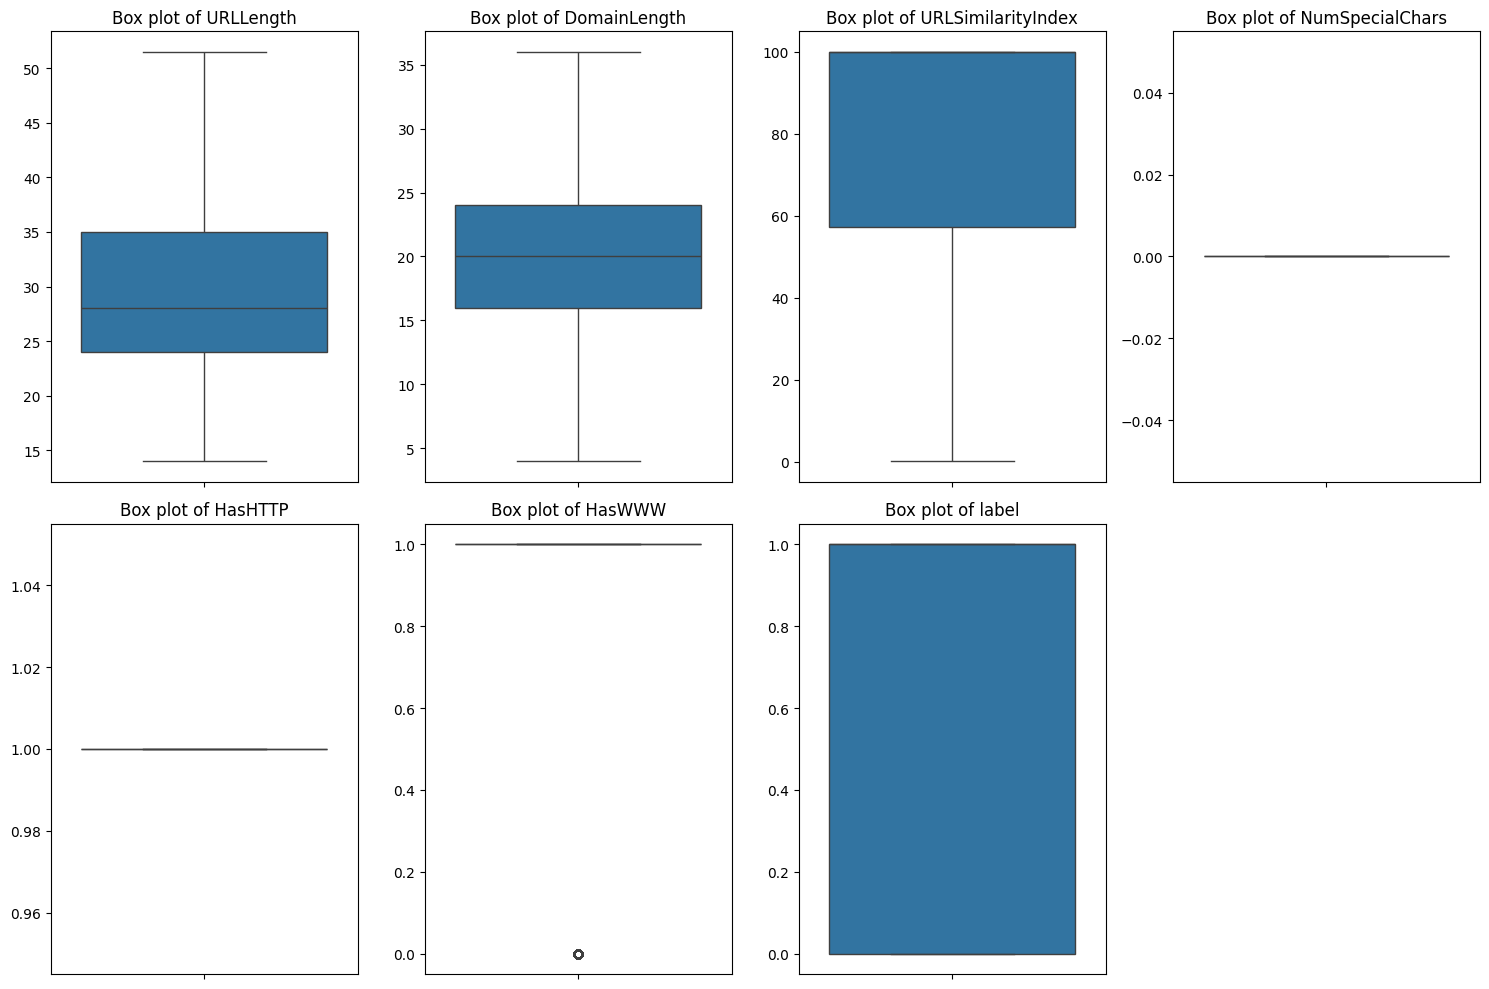

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create box plots for each numerical column to visualize outliers
plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_cols):
    plt.subplot(2, 4, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[column])
    plt.title(f'Box plot of {column}')
    plt.ylabel('')
plt.tight_layout()
plt.show()


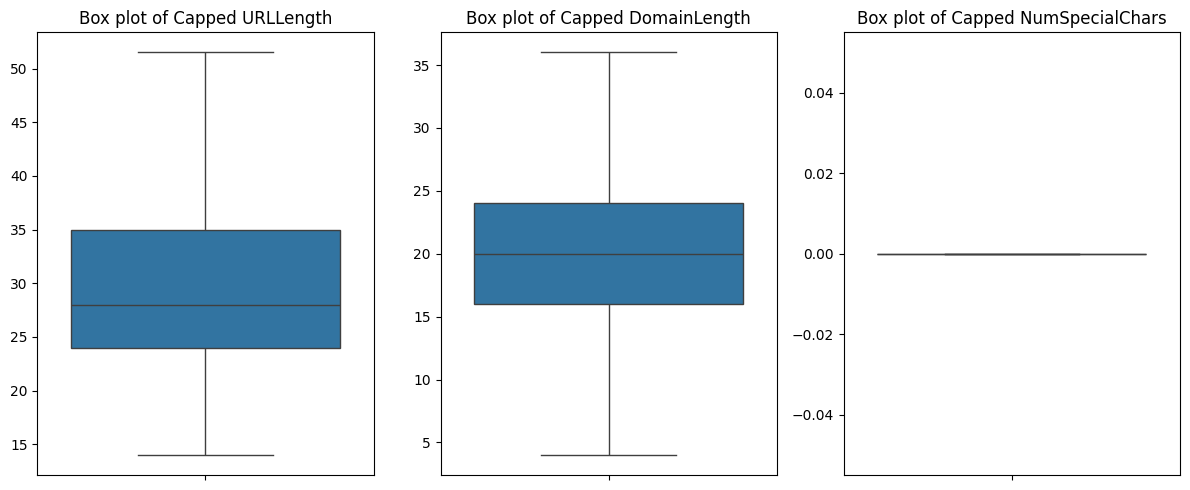

Descriptive statistics for capped numerical columns after visualization:


,URLLength,DomainLength,NumSpecialChars
count,235391.000000,235391.000000,235391.0
mean,30.993402,20.763585,0.0
std,9.254258,6.719343,0.0
min,14.000000,4.000000,0.0
25%,24.000000,16.000000,0.0
50%,28.000000,20.000000,0.0
75%,35.000000,24.000000,0.0
max,51.500000,36.000000,0.0


In [9]:
# Visualize box plots for the capped columns
plt.figure(figsize=(12, 5))
for i, column in enumerate(columns_to_cap):
    plt.subplot(1, len(columns_to_cap), i + 1)
    sns.boxplot(y=df[column])
    plt.title(f'Box plot of Capped {column}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

print("Descriptive statistics for capped numerical columns after visualization:")
display(df[columns_to_cap].describe())

### Explanation of Scaling Methods:

*   **Standardization (StandardScaler):** This method scales features such that they have zero mean (μ=0) and unit variance (σ=1). It's generally preferred when the data follows a Gaussian (normal) distribution. It does not bound values to a specific range, which can be useful when dealing with algorithms that assume normally distributed data.

*   **Normalization (MinMaxScaler):** This method scales features to a fixed range, typically 0 to 1. It's useful when you need to bring all features to a similar scale without making assumptions about their distribution, and it is less affected by outliers than standardization. It works well with algorithms that are not affected by the magnitude of features, but rather by their relative values within a range.

In [10]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Identify numerical feature columns, excluding 'label'
feature_cols = [col for col in numerical_cols if col != 'label']

# Exclude columns with zero standard deviation (e.g., NumSpecialChars after capping)
# Check for std dev before scaling to avoid errors
columns_to_scale = [col for col in feature_cols if df[col].std() != 0]

print(f"Columns selected for scaling: {columns_to_scale}")

# --- Apply StandardScaler (Standardization) ---
print("\nApplying StandardScaler...")
scaler_standard = StandardScaler()
df_standard_scaled = df.copy()
df_standard_scaled[columns_to_scale] = scaler_standard.fit_transform(df[columns_to_scale])

print("Descriptive statistics after StandardScaler:")
display(df_standard_scaled[columns_to_scale].describe())

# --- Apply MinMaxScaler (Normalization) ---
print("\nApplying MinMaxScaler...")
scaler_minmax = MinMaxScaler()
df_minmax_scaled = df.copy()
df_minmax_scaled[columns_to_scale] = scaler_minmax.fit_transform(df[columns_to_scale])

print("Descriptive statistics after MinMaxScaler:")
display(df_minmax_scaled[columns_to_scale].describe())

Columns selected for scaling: ['URLLength', 'DomainLength', 'URLSimilarityIndex', 'HasWWW']

Applying StandardScaler...
Descriptive statistics after StandardScaler:


,URLLength,DomainLength,URLSimilarityIndex,HasWWW
count,2.353910e+05,2.353910e+05,2.353910e+05,2.353910e+05
mean,-1.289530e-16,1.465513e-16,6.249936e-16,1.565729e-16
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,-1.836283e+00,-2.494830e+00,-2.705977e+00,-1.742727e+00
25%,-7.556972e-01,-7.089376e-01,-7.369801e-01,5.738134e-01
50%,-3.234629e-01,-1.136400e-01,7.428756e-01,5.738134e-01
75%,4.329473e-01,4.816575e-01,7.428756e-01,5.738134e-01
max,2.215914e+00,2.267550e+00,7.428756e-01,5.738134e-01



Applying MinMaxScaler...
Descriptive statistics after MinMaxScaler:


,URLLength,DomainLength,URLSimilarityIndex,HasWWW
count,235391.000000,235391.000000,235391.000000,235391.000000
mean,0.453157,0.523862,0.784602,0.752297
std,0.246780,0.209979,0.289952,0.431679
min,0.000000,0.000000,0.000000,0.000000
25%,0.266667,0.375000,0.570914,1.000000
50%,0.373333,0.500000,1.000000,1.000000
75%,0.560000,0.625000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000


### Encode Categorical Variable

The last code cell performed **one-hot encoding** on your categorical data. Here's a breakdown of what happened:

1.  **Identified Categorical Columns:** The code first looked for columns with `object` data types, which typically indicate categorical text data. In your case, it identified `['TLD']` (Top-Level Domain) as the categorical column for encoding.
2.  **Excluded 'URL':** The `URL` column was specifically excluded from encoding because it's usually a unique identifier or highly variable text that isn't suitable for direct one-hot encoding.
3.  **Applied One-Hot Encoding:** Using `pd.get_dummies`, the `TLD` column was transformed. For every unique value in `TLD` (e.g., '.com', '.org', '.net'), a **new binary column** was created. If a row had a particular TLD, its corresponding new column would have a `1`, and all other new TLD columns for that row would have a `0`.
    *   The `drop_first=True` argument was used, which drops the first category to avoid multicollinearity (where one category can be inferred from the others), which is good practice for many machine learning models.
4.  **Resulting DataFrame (`df_encoded`):**
    *   The original `TLD` column was removed.
    *   Instead, **692 new binary columns** (one for each TLD, minus one because of `drop_first=True`) were added to the DataFrame.
    *   This significantly increased the DataFrame's width: from an original shape of `(235391, 9)` to `(235391, 702)`. This new `df_encoded` DataFrame now contains only numerical data, which is required for most machine learning algorithms.

This step is crucial because machine learning models generally require numerical input, and one-hot encoding is a standard way to represent categorical features numerically without implying any ordinal relationship between categories.

In [11]:
print('Original DataFrame shape:', df.shape)

# Identify categorical columns (object type)
categorical_cols = df.select_dtypes(include=['object']).columns

# Exclude 'URL' column as it's not a feature for direct encoding
# Assuming 'URL' is a unique identifier or highly variable text that won't be directly encoded
if 'URL' in categorical_cols:
    categorical_cols = categorical_cols.drop('URL')

print(f"\nCategorical columns identified for encoding: {categorical_cols.tolist()}")

if not categorical_cols.empty:
    # Apply one-hot encoding using pd.get_dummies
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    print('\nDataFrame shape after one-hot encoding:', df_encoded.shape)
    print('\nFirst 5 rows of the DataFrame after encoding:')
    display(df_encoded.head())
else:
    print('\nNo categorical columns found for encoding (excluding URL).')
    df_encoded = df.copy()

Original DataFrame shape: (235391, 9)

Categorical columns identified for encoding: ['TLD']

DataFrame shape after one-hot encoding: (235391, 702)

First 5 rows of the DataFrame after encoding:


,URL,URLLength,DomainLength,URLSimilarityIndex,NumSpecialChars,HasHTTP,HasWWW,label,TLD_101,TLD_103,...,TLD_xyz,TLD_yachts,TLD_ye,TLD_yoga,TLD_youtube,TLD_yt,TLD_za,TLD_zm,TLD_zone,TLD_zw
0,https://www.southbankmosaics.com,32.0,24,100.0,0,1,1,1,False,False,...,False,False,False,False,False,False,False,False,False,False
1,https://www.uni-mainz.de,24.0,16,100.0,0,1,1,1,False,False,...,False,False,False,False,False,False,False,False,False,False
2,https://www.voicefmradio.co.uk,30.0,22,100.0,0,1,1,1,False,False,...,False,False,False,False,False,False,False,False,False,False
3,https://www.sfnmjournal.com,27.0,19,100.0,0,1,1,1,False,False,...,False,False,False,False,False,False,False,False,False,False
4,https://www.rewildingargentina.org,34.0,26,100.0,0,1,1,1,False,False,...,False,False,False,False,False,False,False,False,False,False


### Feature Engineering: Domain-Specific Features

We will now create additional features that are specific to the domain of URL analysis. These features can often provide valuable signals for detecting malicious or suspicious URLs.

In [12]:
from urllib.parse import urlparse

# Function to extract number of subdomains
def get_num_subdomains(url):
    try:
        parsed_url = urlparse(url)
        domain = parsed_url.netloc
        # Remove 'www.' if present, as it's often not considered a true subdomain
        if domain.startswith('www.'):
            domain = domain[4:]
        # Count dots to estimate subdomains, subtracting 1 for the TLD
        return domain.count('.')
    except:
        return 0  # Handle potential parsing errors

# Function to extract number of path segments
def get_num_path_segments(url):
    try:
        parsed_url = urlparse(url)
        path = parsed_url.path
        if not path or path == '/':
            return 0
        # Remove leading/trailing slashes and split by '/' to count segments
        segments = [s for s in path.strip('/').split('/') if s]
        return len(segments)
    except:
        return 0

# Apply the functions to create new features
df['NumSubdomains'] = df['URL'].apply(get_num_subdomains)
df['NumPathSegments'] = df['URL'].apply(get_num_path_segments)

print("New features 'NumSubdomains' and 'NumPathSegments' created.")
print("Descriptive statistics for new features:")
display(df[['NumSubdomains', 'NumPathSegments']].describe())

display(df.head())

New features 'NumSubdomains' and 'NumPathSegments' created.
Descriptive statistics for new features:


,NumSubdomains,NumPathSegments
count,235391.000000,235391.000000
mean,1.414812,0.250783
std,0.677651,0.873049
min,1.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,0.000000
75%,2.000000,0.000000
max,11.000000,33.000000


,URL,URLLength,DomainLength,TLD,URLSimilarityIndex,NumSpecialChars,HasHTTP,HasWWW,label,NumSubdomains,NumPathSegments
0,https://www.southbankmosaics.com,32.0,24,com,100.0,0,1,1,1,1,0
1,https://www.uni-mainz.de,24.0,16,de,100.0,0,1,1,1,1,0
2,https://www.voicefmradio.co.uk,30.0,22,uk,100.0,0,1,1,1,2,0
3,https://www.sfnmjournal.com,27.0,19,com,100.0,0,1,1,1,1,0
4,https://www.rewildingargentina.org,34.0,26,org,100.0,0,1,1,1,1,0


In [13]:
from sklearn.model_selection import train_test_split

# 🔥 IMPORTANT: Remove non-numeric columns (like URL)
X = df_encoded.drop(['label', 'URL'], axis=1)   # <-- FIX HERE
y = df_encoded['label']

# Optional check (VERY IMPORTANT)
print("Data types:\n", X.dtypes)

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Second split: 15% test, 15% validation
X_test, X_val, y_test, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# Print shapes
print("\nShapes:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"X_val: {X_val.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")
print(f"y_val: {y_val.shape}")

Data types:
 URLLength             float64
DomainLength            int64
URLSimilarityIndex    float64
NumSpecialChars         int64
HasHTTP                 int64
                       ...   
TLD_yt                   bool
TLD_za                   bool
TLD_zm                   bool
TLD_zone                 bool
TLD_zw                   bool
Length: 700, dtype: object

Shapes:
X_train: (164773, 700)
X_test: (35309, 700)
X_val: (35309, 700)
y_train: (164773,)
y_test: (35309,)
y_val: (35309,)


## Preprocessing Pipeline Documentation

This notebook has performed a comprehensive data preprocessing pipeline, preparing the dataset for machine learning model training. The key steps include:

1.  **Google Drive Mounting & Data Loading:**
    *   Mounted Google Drive to access files.
    *   Loaded `cleaned_data.csv` into a pandas DataFrame (`df`).

2.  **Missing Data Handling:**
    *   Checked for missing values, confirming the dataset was clean in this aspect.

3.  **Duplicate Handling:**
    *   Identified and removed 404 duplicate rows, resulting in 235,391 unique entries.

4.  **Outlier Detection & Treatment:**
    *   **Detection:** Used the Interquartile Range (IQR) method to identify outliers in numerical columns.
        *   Significant outliers were found in `URLLength`, `DomainLength`, `NumSpecialChars`, and `HasWWW`.
    *   **Treatment (Capping/Winsorization):** Applied capping to `URLLength`, `DomainLength`, and `NumSpecialChars`.
        *   `URLLength` was capped between 14.00 and 51.50.
        *   `DomainLength` was capped between 4.00 and 36.00.
        *   `NumSpecialChars` values were capped to 0 due to extreme outliers.
    *   Visualized outlier treatment using box plots.

5.  **Feature Scaling (Standardization & Normalization):**
    *   Applied `StandardScaler` (standardization) and `MinMaxScaler` (normalization) to selected numerical features (`URLLength`, `DomainLength`, `URLSimilarityIndex`, `HasWWW`).
    *   `label` was excluded as it's the target, and `NumSpecialChars` was excluded due to zero variance after capping.

6.  **Categorical Feature Encoding:**
    *   Identified `TLD` as the categorical column for encoding.
    *   Applied one-hot encoding using `pd.get_dummies(drop_first=True)` to the `TLD` column, generating 692 new binary columns.
    *   The resulting DataFrame, `df_encoded`, now contains only numerical features suitable for machine learning models.

7.  **Feature Engineering: Domain-Specific Features:**
    *   Created two new features from the `URL` column:
        *   `NumSubdomains`: The number of subdomains in the URL.
        *   `NumPathSegments`: The number of path segments in the URL.

8.  **Data Splitting:**
    *   Split the `df_encoded` DataFrame into training, testing, and validation sets.
    *   The split ratio was 70% for training, 15% for testing, and 15% for validation, ensuring stratified sampling based on the `label`.

# *Train Multiple Models*

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


In [15]:
lr = LogisticRegression(solver='saga', max_iter=5000)
svm = SVC(probability=True)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Scale training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit the model again using scaled data
lr.fit(X_train_scaled, y_train)

In [1]:

svm.fit(X_train, y_train)


NameError: name 'svm' is not defined

In [ ]:
rf.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

def evaluate_model(name, model):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# Run evaluation
evaluate_model("Logistic Regression", lr)
evaluate_model("SVM", svm)
evaluate_model("Random Forest", rf)

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

results = []

models = {
    "Logistic Regression": lr,
    "SVM": svm,
    "Random Forest": rf
}

for name, model in models.items():
    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
print(results_df)